# 10 — TITAN: Threshold Indicator Taxa ANalysis

## Method Summary

**TITAN** (Threshold Indicator Taxa ANalysis; Baker & King, 2010) identifies **taxon-specific change points** along an environmental gradient — here, the composite **Pollution Score** computed in Stage 01.

### Core Idea

For a single environmental gradient $x$ (sorted across $n$ sites) and a taxa-by-site abundance matrix $Y$, TITAN asks:

> *At what value of $x$ does each taxon show the sharpest change in occurrence or abundance?*

### Algorithm (per taxon)

1. **Order sites** by increasing $x$ (pollution score).
2. **Candidate partitions** — for each candidate split value $x_c$ (each unique observed value of $x$, excluding the 5 smallest and 5 largest to avoid edge effects):
   - Divide sites into two groups: $x \le x_c$ vs. $x > x_c$.
   - Compute the **Indicator Value** (IndVal; Dufrêne & Legendre, 1997) of the taxon for each side. IndVal combines:
     - **Specificity** $A$: mean abundance in the target group relative to overall mean abundance.
     - **Fidelity** $B$: proportion of sites in the target group where the taxon occurs.
     $$\text{IndVal} = A \times B \times 100$$
   - Compute a **z-score** by comparing the observed IndVal to a null distribution from permuting site labels (typically 250–1000 permutations).

3. **Select the change point** $x_c^*$ that maximises the z-score for each taxon.

4. **Assign direction**:
   - **z−** (negative response): taxon peaks in the *low-$x$* group → decreases past the threshold. These are **sensitive / clean-water indicators**.
   - **z+** (positive response): taxon peaks in the *high-$x$* group → increases past the threshold. These are **tolerant / pollution indicators**.

### Bootstrap Validation

TITAN resamples sites with replacement (default 500 or 1000 bootstrap iterations) to assess:

| Diagnostic | Criterion | Meaning |
|:---|:---|:---|
| **Purity** | ≥ 0.95 | ≥ 95% of bootstrap replicates assign the taxon to the *same* direction (z− or z+) |
| **Reliability** | ≥ 0.95 | ≥ 95% of replicates yield a *significant* response ($p \le 0.05$) |

Only taxa passing **both** filters are retained as reliable threshold indicators.

### Community-Level Thresholds

Summing the filtered z-scores across all reliable taxa in each direction produces:

$$\text{sum}(z^{-}) = \sum_{i \in \text{declining}} z_i^{-}(x), \qquad \text{sum}(z^{+}) = \sum_{j \in \text{increasing}} z_j^{+}(x)$$

The $x$-value where each sum peaks defines the **community-level change point** — the pollution score at which the most dramatic community-wide shift occurs.

### Reference

Baker, M.E. & King, R.S. (2010). A new method for detecting and interpreting biodiversity and ecological community thresholds. *Methods in Ecology and Evolution*, 1, 25–37.

---

## Purpose of This Notebook

We demonstrate TITAN2 on **simulated data** to build intuition for how change-point detection works, before applying it to the real pollution-score gradient in later analyses.

## 1. Setup: Python + R via rpy2

We use `rpy2` to run R code directly inside this Python-kernel notebook via `%%R` magic commands. This allows seamless data exchange between Python and R.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load the rpy2 IPython extension ──
# This enables %%R magic cells and -i / -o flags for data exchange
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [12]:
%%R

# ── Load TITAN2 (install from terminal first if missing:
#    Rscript -e 'install.packages("TITAN2")' ) ──
library(TITAN2)
cat("TITAN2 version:", as.character(packageVersion("TITAN2")), "\n")

TITAN2 version: 2.4.4 


## 2. Simulate Data

We create a synthetic dataset that mimics the real-world scenario:

- **100 sites** sampled along a **pollution-score gradient** $x \in [0, 10]$.
- **20 taxa** with three behavioural archetypes:
  - **Taxa 1–7** (sensitive): abundant at low pollution, decline sharply around $x \approx 3$.
  - **Taxa 8–14** (tolerant): rare at low pollution, increase sharply around $x \approx 6$.
  - **Taxa 15–20** (generalists): no strong threshold — roughly uniform presence.

This setup gives TITAN two community-level thresholds to detect.

In [13]:
np.random.seed(42)

n_sites = 100
n_taxa  = 20
pollution = np.sort(np.random.uniform(0, 10, n_sites))

# ── Helper: abundance from a logistic response curve ──
def logistic_abundance(x, midpoint, steepness, max_abund, increasing=True):
    """Generate Poisson-distributed counts from a logistic occupancy curve."""
    if increasing:
        prob = 1 / (1 + np.exp(-steepness * (x - midpoint)))
    else:
        prob = 1 / (1 + np.exp( steepness * (x - midpoint)))
    lam = max_abund * prob
    return np.random.poisson(lam)

# ── Build taxa matrix ──
taxa_names = [f"Taxon_{i+1:02d}" for i in range(n_taxa)]
taxa_matrix = np.zeros((n_sites, n_taxa), dtype=int)

# Sensitive taxa  (z-): decline around x ≈ 3
for j in range(7):
    mid = np.random.uniform(2.5, 3.5)
    taxa_matrix[:, j] = logistic_abundance(pollution, mid, 2.0, 15, increasing=False)

# Tolerant taxa   (z+): increase around x ≈ 6
for j in range(7, 14):
    mid = np.random.uniform(5.5, 6.5)
    taxa_matrix[:, j] = logistic_abundance(pollution, mid, 2.0, 15, increasing=True)

# Generalist taxa (no threshold): low uniform abundance
for j in range(14, 20):
    taxa_matrix[:, j] = np.random.poisson(3, n_sites)

# ── Assemble DataFrames ──
df_env  = pd.DataFrame({"Pollution_Score": pollution})
df_taxa = pd.DataFrame(taxa_matrix, columns=taxa_names)

print(f"Sites: {n_sites}  |  Taxa: {n_taxa}")
print(f"Pollution range: [{pollution.min():.2f}, {pollution.max():.2f}]")
df_taxa.describe().round(1)

Sites: 100  |  Taxa: 20
Pollution range: [0.06, 9.87]


,Taxon_01,Taxon_02,Taxon_03,Taxon_04,Taxon_05,Taxon_06,Taxon_07,Taxon_08,Taxon_09,Taxon_10,Taxon_11,Taxon_12,Taxon_13,Taxon_14,Taxon_15,Taxon_16,Taxon_17,Taxon_18,Taxon_19,Taxon_20
count,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
mean,4.5,4.5,5.0,5.6,6.0,5.7,5.0,5.2,6.4,6.3,5.0,5.3,6.2,5.3,3.0,2.8,2.8,3.2,2.8,3.0
std,6.1,6.2,6.6,6.7,7.2,6.9,6.7,6.6,7.6,7.6,6.8,7.1,7.6,7.1,1.8,1.6,1.7,1.5,1.8,1.6
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0
50%,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.5,1.0,0.0,0.0,1.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0
75%,10.0,9.2,9.0,11.0,13.0,12.0,10.2,11.0,13.2,13.0,10.0,11.2,12.0,11.0,4.0,4.0,4.0,4.0,4.0,4.0
max,20.0,21.0,24.0,22.0,22.0,22.0,25.0,23.0,28.0,25.0,25.0,27.0,23.0,23.0,8.0,7.0,8.0,7.0,8.0,6.0


## 3. Visualise the Simulated Responses

A quick look at the raw abundance curves confirms the three archetypes before we hand the data to TITAN.

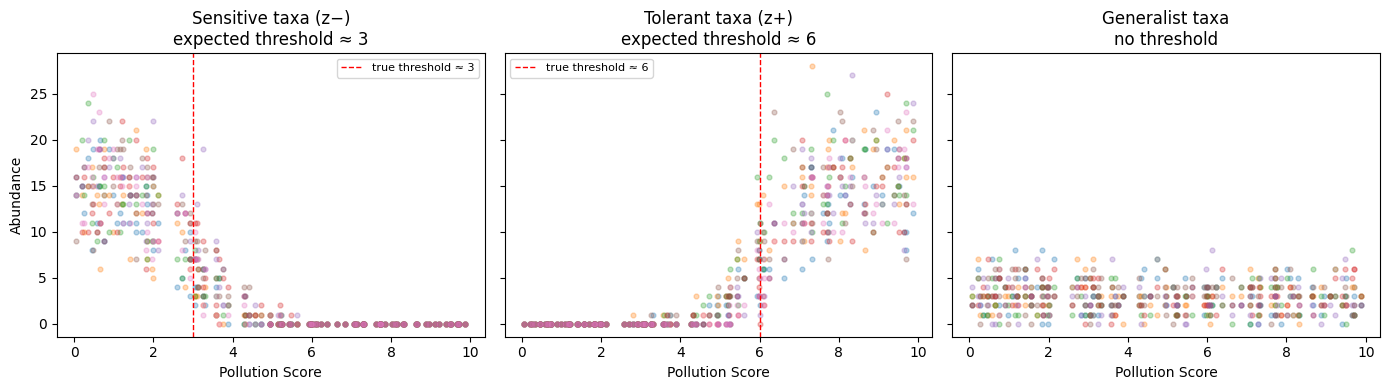

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for j in range(7):
    axes[0].scatter(pollution, taxa_matrix[:, j], alpha=0.3, s=12)
axes[0].set_title("Sensitive taxa (z−)\nexpected threshold ≈ 3")
axes[0].set_xlabel("Pollution Score")
axes[0].set_ylabel("Abundance")
axes[0].axvline(3, ls="--", c="red", lw=1, label="true threshold ≈ 3")
axes[0].legend(fontsize=8)

for j in range(7, 14):
    axes[1].scatter(pollution, taxa_matrix[:, j], alpha=0.3, s=12)
axes[1].set_title("Tolerant taxa (z+)\nexpected threshold ≈ 6")
axes[1].set_xlabel("Pollution Score")
axes[1].axvline(6, ls="--", c="red", lw=1, label="true threshold ≈ 6")
axes[1].legend(fontsize=8)

for j in range(14, 20):
    axes[2].scatter(pollution, taxa_matrix[:, j], alpha=0.3, s=12)
axes[2].set_title("Generalist taxa\nno threshold")
axes[2].set_xlabel("Pollution Score")

plt.tight_layout()
plt.show()

## 4. Run TITAN2 in R

We pass the Python DataFrames `df_env` and `df_taxa` into R using the `-i` flag of `%%R`, then run `titan()`.

- **250 bootstrap replicates** are used here for speed; use ≥ 500 in production.
- The `-i` flag converts pandas DataFrames → R data.frames automatically via `rpy2`.
- The `-o` flag pulls R objects back into the Python namespace.

> **What TITAN does under the hood:**
>
> For every taxon × every candidate split along the pollution gradient, it computes IndVal z-scores.
> The split yielding the **maximum z-score** becomes that taxon's estimated change point.
> Bootstrap resampling then evaluates the **purity** (directional consistency) and **reliability** (statistical significance) of each taxon's response.

In [15]:
%%R -i df_env -i df_taxa -o titan_sppmax

library(TITAN2)

# ── Extract the pollution vector and taxa matrix from the Python DataFrames ──
pollution <- df_env$Pollution_Score
taxa      <- df_taxa

# ── Run TITAN ──
set.seed(123)
tt <- titan(pollution, taxa,
            minSplt  = 5,
            numPerm  = 250,
            boot     = TRUE,
            nBoot    = 250,
            imax     = FALSE,
            ivTot    = FALSE,
            pur.cut  = 0.95,
            rel.cut  = 0.95,
            ncpus    = 1)

# ── Export the taxon-level results back to Python ──
titan_sppmax <- as.data.frame(tt$sppmax)

cat("TITAN run complete.\n")

ℹ Screening taxa...
✔   Taxa frequency screen complete.
ℹ Partitioning along gradient...
ℹ Calculating observed IndVal maxima and class values...
ℹ Calculating IndVals using mean relative abundance...
ℹ Permuting IndVal scores...
ℹ Summarizing observed results...
ℹ Estimating taxa change points using z-score maxima...
ℹ Bootstrap resampling in sequence...
Resampling ■■                                 2% | ETA:  1m
Resampling ■■                                 2% | ETA:  1m
Resampling ■■                                 3% | ETA:  1m
Resampling ■■                                 3% | ETA:  1m
Resampling ■■                                 4% | ETA:  1m
Resampling ■■                                 4% | ETA:  1m
Resampling ■■                                 4% | ETA:  1m
Resampling ■■                                 5% | ETA:  1m
Resampling ■■■                                5% | ETA:  1m
Resampling ■■■                                6% | ETA:  1m
Resampling ■■■                            

## 5. Inspect Taxon-Level Results

The table below is `tt$sppmax` — one row per taxon. Key columns:

| Column | Meaning |
|:---|:---|
| `ienv.cp` | The pollution-score value at the estimated change point |
| `zenv.cp` | The corresponding maximum IndVal z-score |
| `freq`    | Number of sites where the taxon occurs |
| `maxgrp`  | Direction: **1** = z− (sensitive, declining) · **2** = z+ (tolerant, increasing) |
| `zscore`  | Mean z-score across bootstrap replicates |
| `purity`  | Fraction of bootstraps with consistent direction (target ≥ 0.95) |
| `reliability` | Fraction of bootstraps with significant response (target ≥ 0.95) |
| `5%`, `50%`, `95%` | Bootstrap quantiles of the change-point estimate |

In [16]:
# ── The R data.frame `titan_sppmax` is now a pandas DataFrame via rpy2 ──
titan_df = titan_sppmax.copy()

# Rename direction for readability
titan_df["direction"] = titan_df["maxgrp"].map({1: "z− (sensitive)", 2: "z+ (tolerant)"})

display_cols = ["ienv.cp", "zenv.cp", "freq", "direction", "purity", "reliability", "5%", "50%", "95%"]
cols_present = [c for c in display_cols if c in titan_df.columns]
titan_df[cols_present].round(3)

,ienv.cp,zenv.cp,freq,direction,purity,reliability,5%,50%,95%
Taxon_01,3.816,3.078,47.0,z− (sensitive),1.000,1.000,3.181,3.745,4.503
Taxon_02,3.624,3.078,51.0,z− (sensitive),1.000,1.000,3.132,3.656,5.172
Taxon_03,4.081,4.641,49.0,z− (sensitive),1.000,1.000,3.253,3.887,4.830
Taxon_04,4.830,4.641,53.0,z− (sensitive),1.000,1.000,3.585,4.421,5.142
Taxon_05,4.641,5.237,54.0,z− (sensitive),1.000,1.000,3.575,4.415,5.233
Taxon_06,4.830,4.641,51.0,z− (sensitive),1.000,1.000,3.585,4.501,5.047
Taxon_07,3.624,3.078,47.0,z− (sensitive),1.000,1.000,3.115,3.664,4.481
Taxon_08,5.337,5.237,51.0,z+ (tolerant),1.000,1.000,4.297,5.044,5.952
Taxon_09,4.297,4.641,55.0,z+ (tolerant),1.000,1.000,4.081,4.641,5.327
Taxon_10,4.360,5.237,54.0,z+ (tolerant),1.000,1.000,3.942,4.749,5.343


## 6. TITAN Diagnostic Plots

### 6a. Taxon-Specific Change Points (`plot_taxa`)

Each horizontal bar represents one taxon's **bootstrap distribution** of change-point estimates:
- **Blue bars** = z− (sensitive / declining taxa) — change points should cluster near $x \approx 3$.
- **Red bars** = z+ (tolerant / increasing taxa) — change points should cluster near $x \approx 6$.
- Filled circles mark the **median** bootstrap change point; whiskers span the 5th–95th percentiles.
- Only taxa passing the purity and reliability filters are shown with filled symbols.

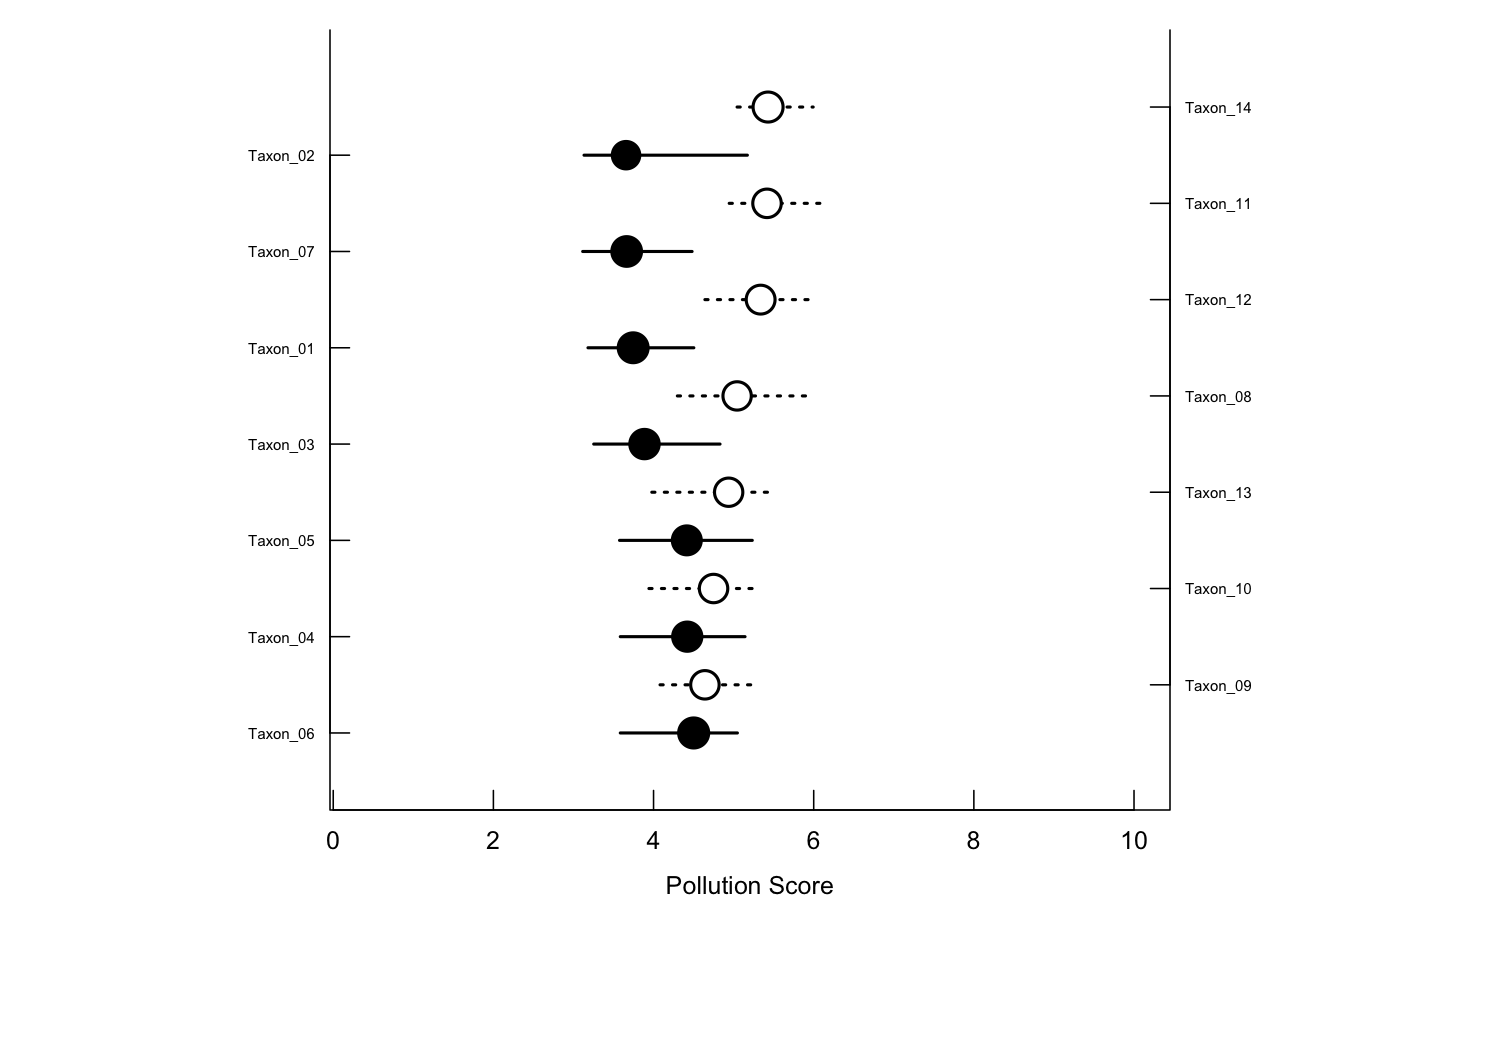

In [17]:
%%R -w 10 -h 7 --units in -r 150

# ── Taxon change-point plot (rendered inline via rpy2) ──
plot_taxa(tt, z.med = TRUE, xlabel = "Pollution Score")

### 6b. Community-Level Sum(z) (`plot_sumz`)

This plot shows the **sum of z-scores** across all filtered taxa at each candidate split point:

- **Blue curve** = $\sum z^{-}$: peaks where sensitive taxa collectively show the sharpest decline → **community threshold for degradation onset**.
- **Red curve** = $\sum z^{+}$: peaks where tolerant taxa collectively show the sharpest increase → **community threshold for degradation dominance**.

The x-values at these peaks are the **community-level change points**.

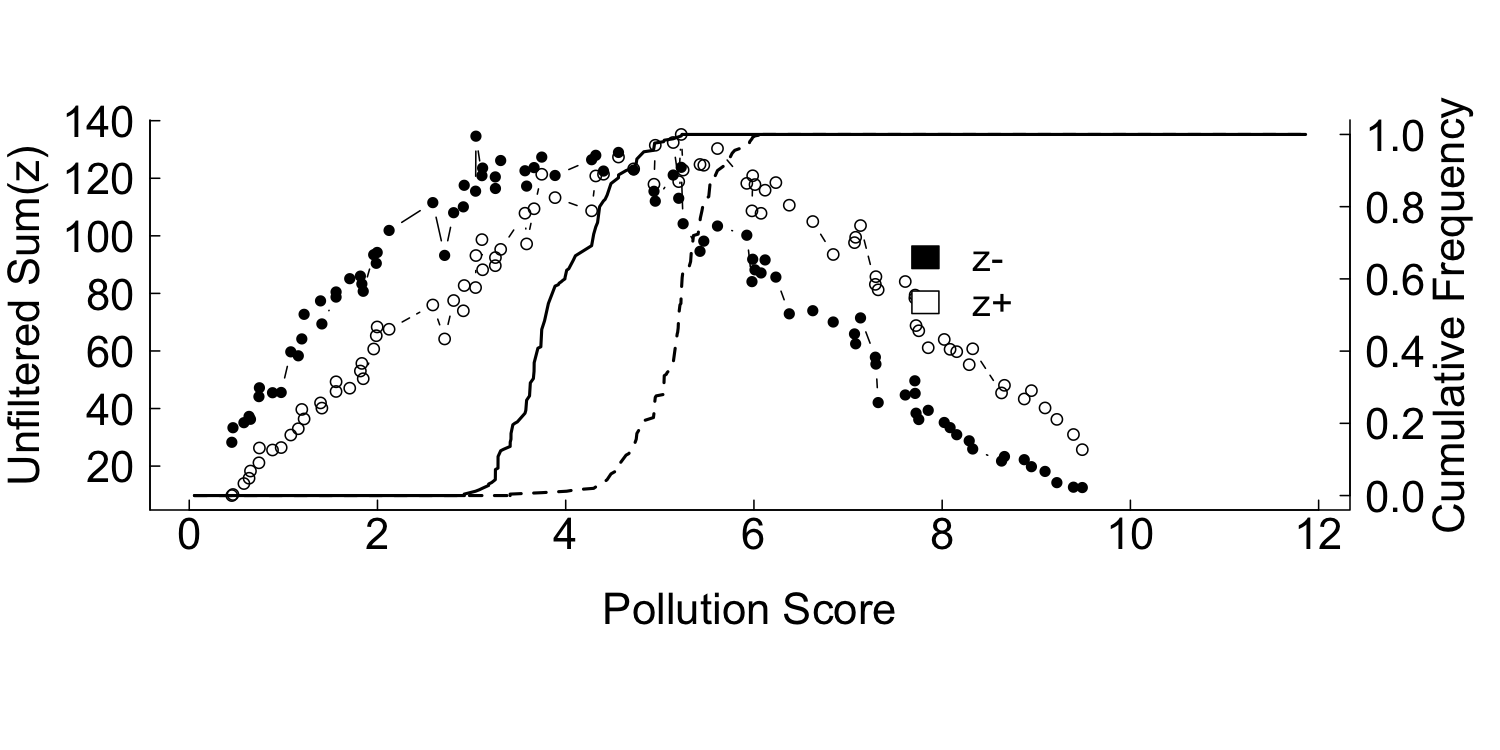

In [18]:
%%R -w 10 -h 5 --units in -r 150

# ── Community-level sum(z) plot (rendered inline via rpy2) ──
plot_sumz(tt, xlabel = "Pollution Score")

## 7. Summary of What TITAN Detected

Let us compare the **known** simulation thresholds with what TITAN recovered.

In [19]:
# ── Compare true vs. estimated thresholds ──
sensitive = titan_df[titan_df["maxgrp"] == 1]
tolerant  = titan_df[titan_df["maxgrp"] == 2]

print("=" * 60)
print("  SIMULATED vs. TITAN-ESTIMATED THRESHOLDS")
print("=" * 60)

print(f"\n  Sensitive taxa (z−):")
print(f"    True threshold range:      2.5 – 3.5")
if len(sensitive) > 0:
    med_col = "50%" if "50%" in sensitive.columns else "ienv.cp"
    print(f"    TITAN median change-point:  {sensitive[med_col].median():.2f}")
    print(f"    Number detected:           {len(sensitive)}")
else:
    print("    (none detected)")

print(f"\n  Tolerant taxa (z+):")
print(f"    True threshold range:      5.5 – 6.5")
if len(tolerant) > 0:
    med_col = "50%" if "50%" in tolerant.columns else "ienv.cp"
    print(f"    TITAN median change-point:  {tolerant[med_col].median():.2f}")
    print(f"    Number detected:           {len(tolerant)}")
else:
    print("    (none detected)")

# Check generalists — they should mostly fail the purity/reliability filter
if "purity" in titan_df.columns and "reliability" in titan_df.columns:
    generalist_names = [f"Taxon_{i+1:02d}" for i in range(14, 20)]
    gen_df = titan_df.loc[titan_df.index.isin(generalist_names)]
    n_filtered_out = ((gen_df["purity"] < 0.95) | (gen_df["reliability"] < 0.95)).sum()
    print(f"\n  Generalist taxa filtered out by purity/reliability: {n_filtered_out}/{len(gen_df)}")

print("\n" + "=" * 60)

  SIMULATED vs. TITAN-ESTIMATED THRESHOLDS

  Sensitive taxa (z−):
    True threshold range:      2.5 – 3.5
    TITAN median change-point:  3.66
    Number detected:           13

  Tolerant taxa (z+):
    True threshold range:      5.5 – 6.5
    TITAN median change-point:  5.04
    Number detected:           7

  Generalist taxa filtered out by purity/reliability: 6/6



---

## Key Take-Aways

1. **TITAN identifies taxon-specific thresholds** — each taxon gets its own change point along the gradient, not just a single community-wide breakpoint.

2. **Two community-level change points** emerge from summing z-scores:
   - The **$\sum z^{-}$ peak** marks where sensitive taxa collectively begin to disappear (degradation onset).
   - The **$\sum z^{+}$ peak** marks where tolerant taxa collectively dominate (degradation dominance).

3. **Bootstrap filtering** (purity ≥ 0.95, reliability ≥ 0.95) removes taxa with inconsistent or non-significant responses — including most generalists.

4. **Application to this thesis**: The environmental gradient will be the **Pollution Score** computed in Stage 01. TITAN will reveal which benthic invertebrate taxa are the most reliable indicators of contamination thresholds in the Detroit River / Lake St. Clair system.

---
## Part 2: TITAN Analysis on Real Study Data

We now apply TITAN2 to the real benthic macroinvertebrate data from the Detroit River / Lake St. Clair corridor to detect **community change points** along two gradients:

1. **Pollution Score → Community Thresholds**: Identifies the pollution level at which the benthic community undergoes the most significant compositional change within each cluster.
2. **ZCI → Community Thresholds**: Identifies the ZCI value where community composition changes most dramatically — revealing a "critical" ZCI threshold per cluster.

**Methodological choices:**
- **Cluster assignment** uses `Predicted_Cluster` from Stage 3 (LDA classification) so all 233 sites are included.
- **Extreme trimming**: Bottom 20 % and top 20 % of Pollution Scores are excluded to focus TITAN on the interior gradient where threshold detection is most reliable.
- **Taxa data** is converted from octave-transformed values to **relative abundances** via `octave_to_relative_abundance()`.
- **Bootstrap**: `nBoot = 100` for exploration; increase to ≥ 500 for publication-quality results.

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from zci.core.transforms import octave_to_relative_abundance

# ── Paths ─────────────────────────────────────────────────────────────
base_path = '../data/processed/complete_env_taxa_chemical_Feb_3.xlsx'
d1_path   = '../results/01_pollution_assessment/artifacts/01_updated_data.xlsx'
d3_path   = '../results/03_LDA_Classification/artifacts/03_updated_data.xlsx'
d4_path   = '../results/04_bray_curtis_NMDS/artifacts/04_updated_data.xlsx'

# ── Load ──────────────────────────────────────────────────────────────
base = pd.read_excel(base_path, header=[0,1,2], index_col=0)
d1   = pd.read_excel(d1_path,   header=[0,1,2], index_col=0)
d3   = pd.read_excel(d3_path,   header=[0,1,2], index_col=0)
d4   = pd.read_excel(d4_path,   header=[0,1,2], index_col=0)

# ── Flatten key columns ──────────────────────────────────────────────
pollution_score   = d1.xs('Pollution_Score',   level=2, axis=1).iloc[:, 0].rename('Pollution_Score')
predicted_cluster = d3.xs('Predicted_Cluster', level=2, axis=1).iloc[:, 0].rename('Cluster')
zci               = d4.xs('ZCI',               level=2, axis=1).iloc[:, 0].rename('ZCI')

# ── Taxa: octave → relative abundance ────────────────────────────────
taxa_cols = [c for c in base.columns if c[0] == 'taxa']
taxa_oct  = base[taxa_cols].copy()
taxa_oct.columns = [c[2] for c in taxa_oct.columns]          # flatten names
taxa_ra   = octave_to_relative_abundance(taxa_oct)
# R-safe column names (replace spaces with underscores)
taxa_ra.columns = [c.replace(' ', '_') for c in taxa_ra.columns]

# ── Merge ─────────────────────────────────────────────────────────────
df_real = pd.concat([pollution_score, predicted_cluster, zci, taxa_ra], axis=1)
df_real.dropna(subset=['Pollution_Score', 'Cluster', 'ZCI'], inplace=True)
df_real['Cluster'] = df_real['Cluster'].astype(int)
taxa_names_real = list(taxa_ra.columns)

print(f"Merged dataset : {df_real.shape[0]} sites × {df_real.shape[1]} columns")
print(f"Pollution Score : [{df_real['Pollution_Score'].min():.3f}, {df_real['Pollution_Score'].max():.3f}]")
print(f"ZCI             : [{df_real['ZCI'].min():.4f}, {df_real['ZCI'].max():.4f}]")
print(f"\nCluster distribution:")
for cl in sorted(df_real['Cluster'].unique()):
    print(f"  Cluster {cl}: {(df_real['Cluster']==cl).sum()} sites")
print(f"\n{len(taxa_names_real)} taxa: {taxa_names_real}")

Merged dataset : 233 sites × 19 columns
Pollution Score : [1.501, 3.752]
ZCI             : [0.0377, 0.7969]

Cluster distribution:
  Cluster 1: 204 sites
  Cluster 2: 29 sites

16 taxa: ['Acari', 'Amphipoda', 'Caenis', 'Ceratopogonidae', 'Chironomidae', 'Dreissena', 'Gastropoda', 'Hexagenia', 'Hirudinea', 'Hydropsychidae', 'Hydrozoa', 'Nematoda', 'Oligochaeta', 'Other_Trichoptera', 'Sphaeriidae', 'Turbellaria']


In [34]:
# ── Global trimming: 20th–80th percentile of Pollution Score ─────────
q20 = df_real['Pollution_Score'].quantile(0.05)
q80 = df_real['Pollution_Score'].quantile(0.90)
df_trimmed = df_real.query("@q20 <= Pollution_Score <= @q80").copy()

print(f"Pollution Score trimming → [{q20:.3f}, {q80:.3f}]  (20th – 80th percentile)")
print(f"Sites: {df_real.shape[0]} → {df_trimmed.shape[0]}")

# ── Per-cluster summary ──────────────────────────────────────────────
MIN_SITES = 15          # lowered to include smaller clusters
viable_clusters = []
for cl in sorted(df_trimmed['Cluster'].unique()):
    n = (df_trimmed['Cluster'] == cl).sum()
    ok = n >= MIN_SITES
    if ok:
        viable_clusters.append(cl)
    print(f"  Cluster {cl}: {n:3d} sites  {'✓ viable for TITAN' if ok else '✗ too few'}")
print(f"\nViable clusters: {viable_clusters}")

# ── Remove taxa with < 3 non-zero occurrences across trimmed data ────
drop_taxa = [t for t in taxa_names_real if (df_trimmed[t] > 0).sum() < 3]
if drop_taxa:
    print(f"Dropped zero/near-zero taxa: {drop_taxa}")
    titan_input = df_trimmed.drop(columns=drop_taxa)
    active_taxa = [t for t in taxa_names_real if t not in drop_taxa]
else:
    titan_input = df_trimmed.copy()
    active_taxa = taxa_names_real[:]
    print("All taxa retained (≥ 3 occurrences each)")

print(f"\nTITAN input ready: {titan_input.shape[0]} sites × {len(active_taxa)} taxa")

Pollution Score trimming → [2.021, 3.294]  (20th – 80th percentile)
Sites: 233 → 185
  Cluster 1: 161 sites  ✓ viable for TITAN
  Cluster 2:  24 sites  ✓ viable for TITAN

Viable clusters: [np.int64(1), np.int64(2)]
All taxa retained (≥ 3 occurrences each)

TITAN input ready: 185 sites × 16 taxa


/var/folders/s5/r1s56_ps46lbbv1370hjn_vr0000gn/T/ipykernel_2272/97176524.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


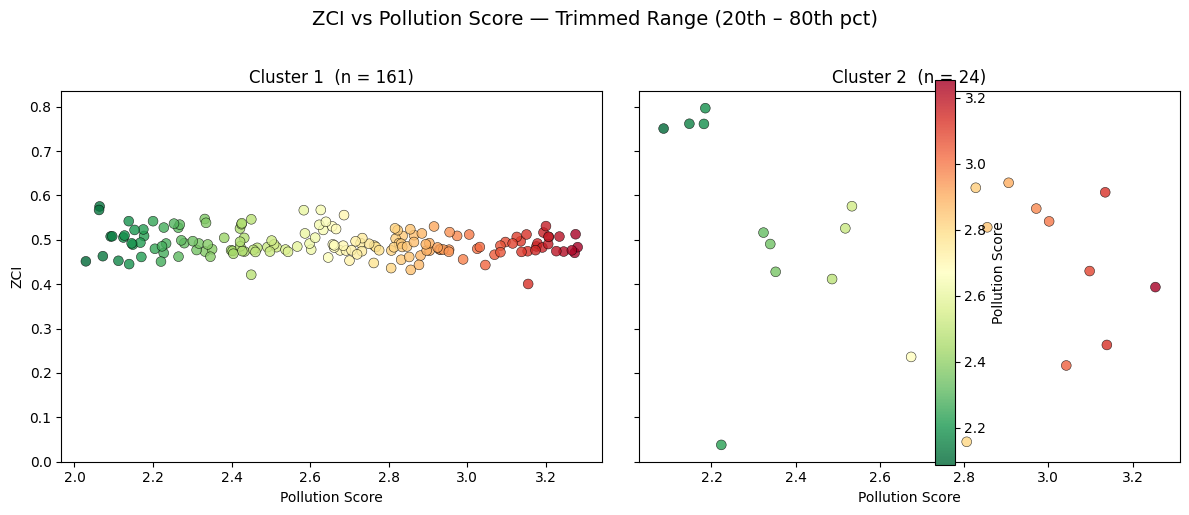

In [35]:
# ── Pre-TITAN scatter: ZCI vs Pollution Score per cluster ─────────────
fig, axes = plt.subplots(1, len(viable_clusters),
                          figsize=(6 * len(viable_clusters), 5),
                          squeeze=False, sharey=True)
for i, cl in enumerate(viable_clusters):
    ax  = axes[0, i]
    sub = titan_input[titan_input['Cluster'] == cl]
    sc  = ax.scatter(sub['Pollution_Score'], sub['ZCI'],
                     c=sub['Pollution_Score'], cmap='RdYlGn_r',
                     edgecolor='k', linewidth=0.4, s=50, alpha=0.8)
    ax.set_xlabel('Pollution Score')
    ax.set_ylabel('ZCI' if i == 0 else '')
    ax.set_title(f'Cluster {cl}  (n = {len(sub)})')
fig.colorbar(sc, ax=axes.ravel().tolist(), label='Pollution Score')
fig.suptitle('ZCI vs Pollution Score — Trimmed Range (20th – 80th pct)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.1  TITAN with Pollution Score as Gradient

We use **Pollution Score** as the environmental gradient and the 16-taxa relative-abundance matrix as the community response. TITAN detects:

- **z⁻ threshold**: the Pollution Score above which *sensitive* (decreasing) taxa begin to decline.
- **z⁺ threshold**: the Pollution Score above which *tolerant* (increasing) taxa begin to increase.

These community-level thresholds reveal the **critical pollution levels** for community restructuring in each cluster.

In [37]:
%%R -i titan_input -o sumz_ps_df

library(TITAN2)

clusters  <- sort(unique(titan_input$Cluster))
taxa_cols <- setdiff(names(titan_input), c("Pollution_Score", "ZCI", "Cluster"))

sumz_ps_df       <- data.frame()
titan_ps_objects <- list()          # kept in R env for plotting later

for (cl in clusters) {
    sub <- titan_input[titan_input$Cluster == cl, ]
    n   <- nrow(sub)
    if (n < 15) {
        cat("Cluster", cl, ":", n, "sites — skipping (< 15)\n\n")
        next
    }

    env <- sub$Pollution_Score
    txa <- sub[, taxa_cols, drop = FALSE]

    # drop taxa with < 3 non-zero values in this cluster
    keep <- colSums(txa > 0) >= 3
    txa  <- txa[, keep, drop = FALSE]

    cat("━━━ Cluster", cl, ":", n, "sites,", ncol(txa), "taxa ━━━\n")

    res <- tryCatch({
        titan(env, txa,
              minSplt = 5, numPerm = 250,
              boot = TRUE, nBoot = 100,
              imax = FALSE, ivTot = FALSE,
              pur.cut = 0.95, rel.cut = 0.95, ncpus = 1)
    }, error = function(e) {
        cat("  ⚠ TITAN failed:", conditionMessage(e), "\n\n")
        return(NULL)
    })

    if (is.null(res)) next
    titan_ps_objects[[as.character(cl)]] <- res

    cp  <- res$sumz.cp
    row <- data.frame(
        Cluster   = cl,
        n_sites   = n,
        n_taxa    = ncol(txa),
        zminus_cp = cp["fsumz-", "cp"],
        zminus_05 = cp["fsumz-", "0.05"],
        zminus_95 = cp["fsumz-", "0.95"],
        zplus_cp  = cp["fsumz+", "cp"],
        zplus_05  = cp["fsumz+", "0.05"],
        zplus_95  = cp["fsumz+", "0.95"]
    )
    sumz_ps_df <- rbind(sumz_ps_df, row)

    cat("  z- threshold:", round(cp["fsumz-","cp"], 3),
        " [", round(cp["fsumz-","0.05"], 3), ",", round(cp["fsumz-","0.95"], 3), "]\n")
    cat("  z+ threshold:", round(cp["fsumz+","cp"], 3),
        " [", round(cp["fsumz+","0.05"], 3), ",", round(cp["fsumz+","0.95"], 3), "]\n\n")
}

cat("\n=== Community Thresholds (Pollution Score gradient) ===\n")
print(sumz_ps_df)

━━━ Cluster 1 : 161 sites, 16 taxa ━━━
ℹ Screening taxa...
→   100% occurrence detected 16 times (100% of taxa),
→   use of TITAN less than ideal for this data type.
✔   Taxa frequency screen complete.
ℹ Partitioning along gradient...
ℹ Calculating observed IndVal maxima and class values...
ℹ Calculating IndVals using mean relative abundance...
ℹ Permuting IndVal scores...
ℹ Summarizing observed results...
ℹ Estimating taxa change points using z-score maxima...
ℹ Bootstrap resampling in sequence...
Resampling ■■                                 2% | ETA:  1m
Resampling ■■                                 3% | ETA:  1m
Resampling ■■                                 4% | ETA:  1m
Resampling ■■■                                5% | ETA:  1m
Resampling ■■■                                6% | ETA:  1m
Resampling ■■■                                7% | ETA:  1m
Resampling ■■■                                8% | ETA:  1m
Resampling ■■■■                               9% | ETA:  1m
Resampling ■■■■ 

In addition: Warning messages:
1: Low number of pure and reliable taxa, sum(z) output should be interpreted with
caution 
2: Low number of pure and reliable taxa, sum(z) output should be interpreted with
caution 


In [38]:
# ── Display community thresholds (Pollution Score gradient) ───────────
print("Community-Level Thresholds — Pollution Score Gradient")
print("=" * 70)
display(
    sumz_ps_df.style
    .format({c: '{:.3f}' for c in sumz_ps_df.columns if c not in ('Cluster','n_sites','n_taxa')})
    .set_caption("TITAN Community Thresholds on Pollution Score")
)

Community-Level Thresholds — Pollution Score Gradient


,Cluster,n_sites,n_taxa,zminus_cp,zminus_05,zminus_95,zplus_cp,zplus_05,zplus_95
1,1,161,16,2.343,2.173,2.726,2.680,2.655,3.217
2,2,24,16,nan,nan,nan,nan,nan,nan



━━━ Cluster 1 — Taxa Change Points (Pollution Score) ━━━

━━━ Cluster 1 — Community Sum(z) (Pollution Score) ━━━

━━━ Cluster 2 — Taxa Change Points (Pollution Score) ━━━
  ⚠ plot_taxa skipped: z1 is empty, set z1=FALSE, change significance criteria, or set
boot=FALSE if bootstrapping was not used to generate the titan object. 

━━━ Cluster 2 — Community Sum(z) (Pollution Score) ━━━


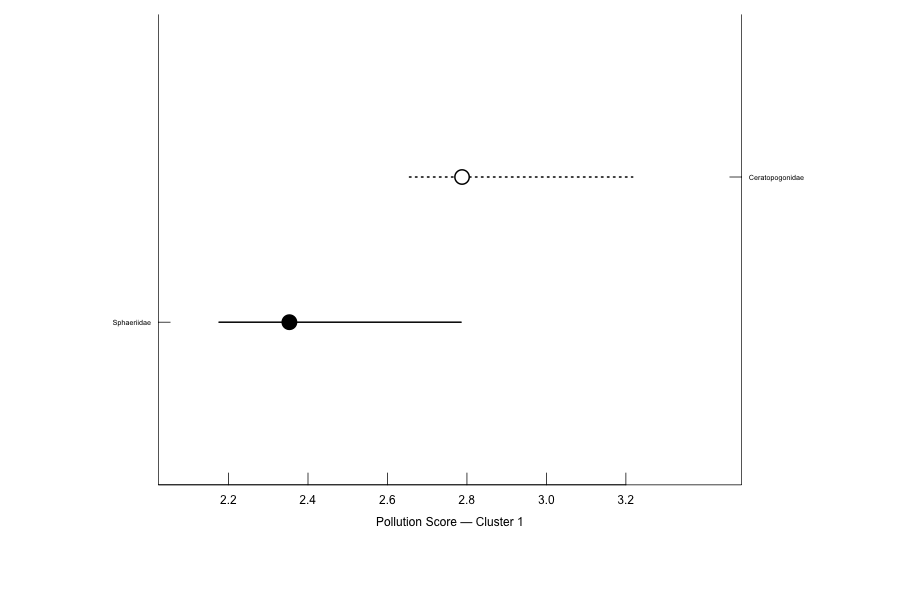

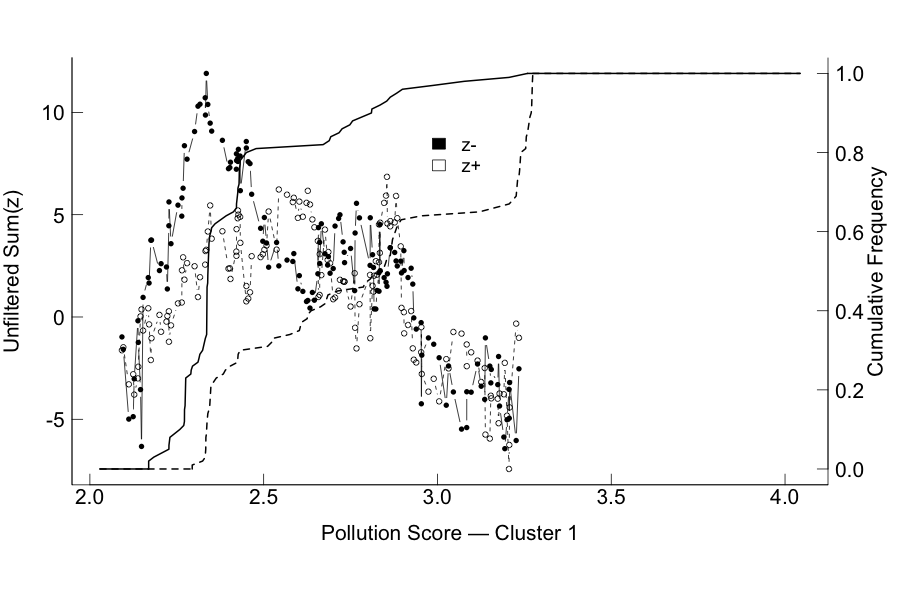

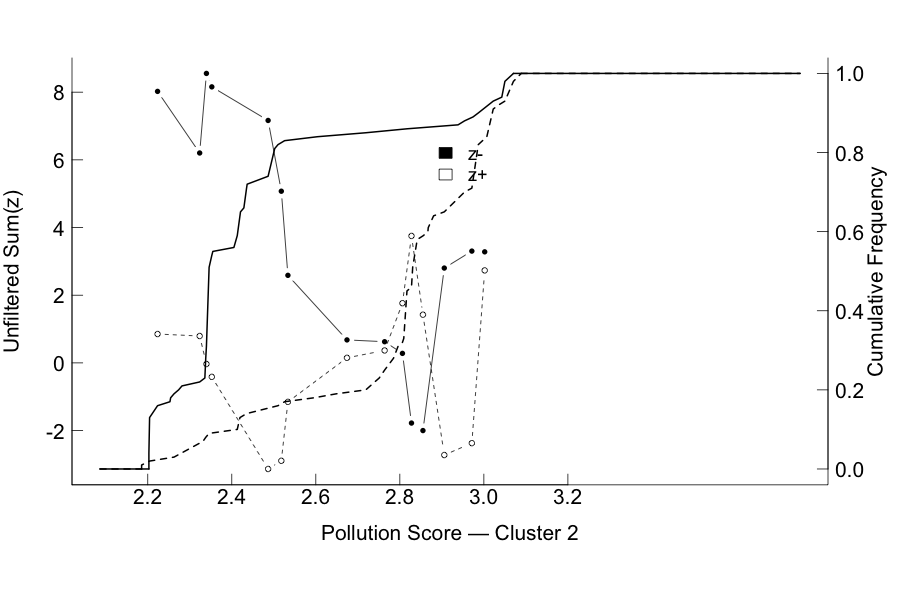

In [39]:
%%R -w 900 -h 600

# ── TITAN diagnostic plots: Pollution Score gradient ─────────────────
clusters_done_ps <- names(titan_ps_objects)

for (cl in clusters_done_ps) {
    res <- titan_ps_objects[[cl]]

    tryCatch({
        cat("\n━━━ Cluster", cl, "— Taxa Change Points (Pollution Score) ━━━\n")
        plot_taxa(res, xlabel = paste("Pollution Score — Cluster", cl))
    }, error = function(e) {
        cat("  ⚠ plot_taxa skipped:", conditionMessage(e), "\n")
    })

    tryCatch({
        cat("\n━━━ Cluster", cl, "— Community Sum(z) (Pollution Score) ━━━\n")
        plot_sumz(res, xlabel = paste("Pollution Score — Cluster", cl))
    }, error = function(e) {
        cat("  ⚠ plot_sumz skipped:", conditionMessage(e), "\n")
    })
}

### 2.2  TITAN with ZCI as Gradient

Now we flip the perspective: use **ZCI** as the gradient to ask *"at what ZCI value does the community composition change most dramatically?"*

This directly identifies the **ZCI threshold** — the community-integrity breakpoint within each cluster. The expectation is that the conditional distribution of Pollution Scores should shift at this ZCI threshold.

In [40]:
%%R -i titan_input -o sumz_zci_df

clusters  <- sort(unique(titan_input$Cluster))
taxa_cols <- setdiff(names(titan_input), c("Pollution_Score", "ZCI", "Cluster"))

sumz_zci_df       <- data.frame()
titan_zci_objects <- list()

for (cl in clusters) {
    sub <- titan_input[titan_input$Cluster == cl, ]
    n   <- nrow(sub)
    if (n < 15) {
        cat("Cluster", cl, ":", n, "sites — skipping (< 15)\n\n")
        next
    }

    env <- sub$ZCI
    txa <- sub[, taxa_cols, drop = FALSE]

    keep <- colSums(txa > 0) >= 3
    txa  <- txa[, keep, drop = FALSE]

    cat("━━━ Cluster", cl, ":", n, "sites,", ncol(txa), "taxa ━━━\n")

    res <- tryCatch({
        titan(env, txa,
              minSplt = 5, numPerm = 250,
              boot = TRUE, nBoot = 100,
              imax = FALSE, ivTot = FALSE,
              pur.cut = 0.95, rel.cut = 0.95, ncpus = 1)
    }, error = function(e) {
        cat("  ⚠ TITAN failed:", conditionMessage(e), "\n\n")
        return(NULL)
    })

    if (is.null(res)) next
    titan_zci_objects[[as.character(cl)]] <- res

    cp  <- res$sumz.cp
    row <- data.frame(
        Cluster   = cl,
        n_sites   = n,
        n_taxa    = ncol(txa),
        zminus_cp = cp["fsumz-", "cp"],
        zminus_05 = cp["fsumz-", "0.05"],
        zminus_95 = cp["fsumz-", "0.95"],
        zplus_cp  = cp["fsumz+", "cp"],
        zplus_05  = cp["fsumz+", "0.05"],
        zplus_95  = cp["fsumz+", "0.95"]
    )
    sumz_zci_df <- rbind(sumz_zci_df, row)

    cat("  z- threshold:", round(cp["fsumz-","cp"], 4),
        " [", round(cp["fsumz-","0.05"], 4), ",", round(cp["fsumz-","0.95"], 4), "]\n")
    cat("  z+ threshold:", round(cp["fsumz+","cp"], 4),
        " [", round(cp["fsumz+","0.05"], 4), ",", round(cp["fsumz+","0.95"], 4), "]\n\n")
}

cat("\n=== Community Thresholds (ZCI gradient) ===\n")
print(sumz_zci_df)

━━━ Cluster 1 : 161 sites, 16 taxa ━━━
ℹ Screening taxa...
→   100% occurrence detected 16 times (100% of taxa),
→   use of TITAN less than ideal for this data type.
✔   Taxa frequency screen complete.
ℹ Partitioning along gradient...
ℹ Calculating observed IndVal maxima and class values...
ℹ Calculating IndVals using mean relative abundance...
ℹ Permuting IndVal scores...
ℹ Summarizing observed results...
ℹ Estimating taxa change points using z-score maxima...
ℹ Bootstrap resampling in sequence...
Resampling ■■                                 2% | ETA:  1m
Resampling ■■                                 3% | ETA:  1m
Resampling ■■                                 4% | ETA:  1m
Resampling ■■■                                5% | ETA:  1m
Resampling ■■■                                6% | ETA:  1m
Resampling ■■■                                7% | ETA:  1m
Resampling ■■■                                8% | ETA:  1m
Resampling ■■■■                               9% | ETA:  1m
Resampling ■■■■ 

In addition: Warning message:
Low number of pure and reliable taxa, sum(z) output should be interpreted with
caution 


In [42]:
# ── Display community thresholds (ZCI gradient) ─────────────────────
print("Community-Level Thresholds — ZCI Gradient")
print("=" * 70)
display(
    sumz_zci_df.style
    .format({c: '{:.4f}' for c in sumz_zci_df.columns if c not in ('Cluster','n_sites','n_taxa')})
    .set_caption("TITAN Community Thresholds on ZCI")
)

Community-Level Thresholds — ZCI Gradient


,Cluster,n_sites,n_taxa,zminus_cp,zminus_05,zminus_95,zplus_cp,zplus_05,zplus_95
1,1,161,16,0.4908,0.4894,0.5049,0.4962,0.4925,0.5033
2,2,24,16,0.5034,0.4601,0.5666,0.5211,0.2495,0.5562



━━━ Cluster 1 — Taxa Change Points (ZCI) ━━━

━━━ Cluster 1 — Community Sum(z) (ZCI) ━━━

━━━ Cluster 2 — Taxa Change Points (ZCI) ━━━

━━━ Cluster 2 — Community Sum(z) (ZCI) ━━━


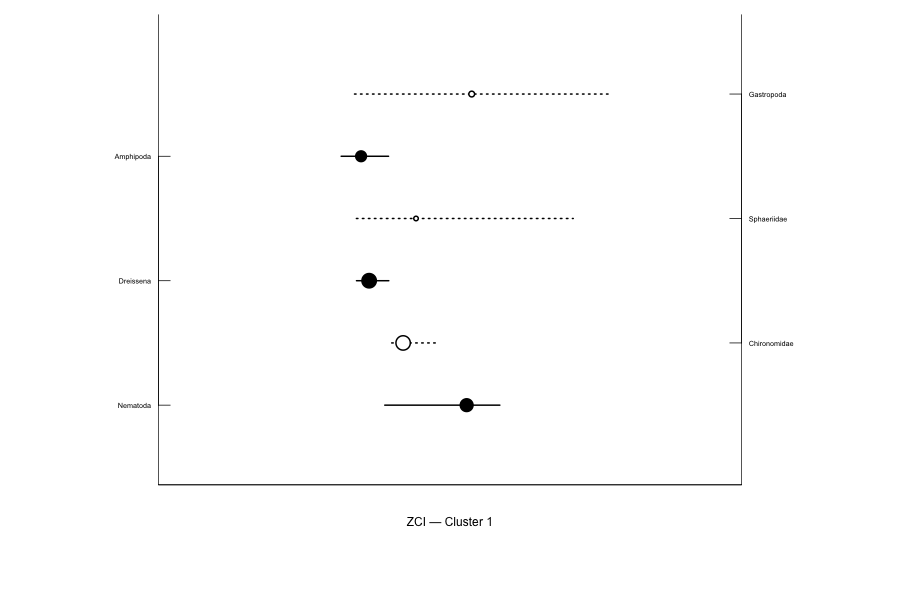

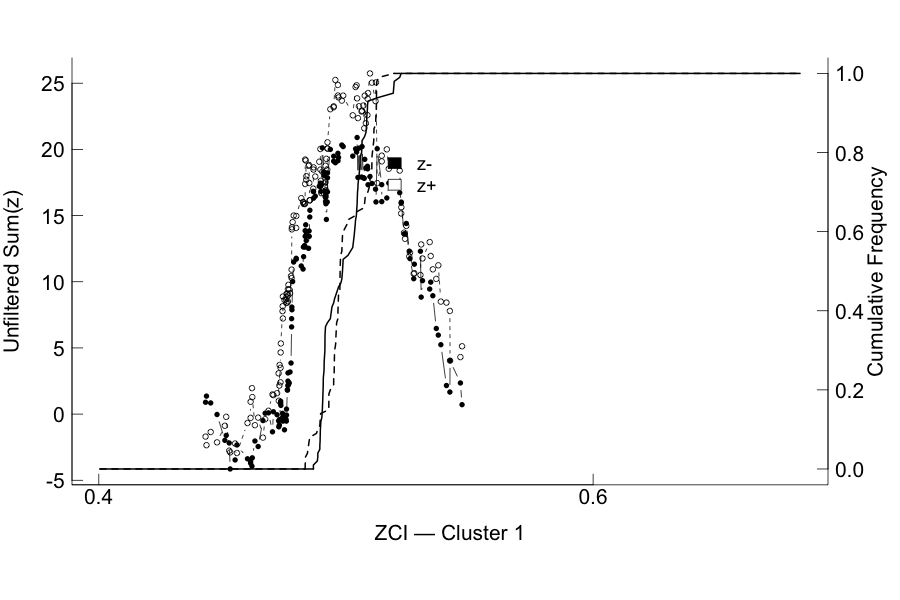

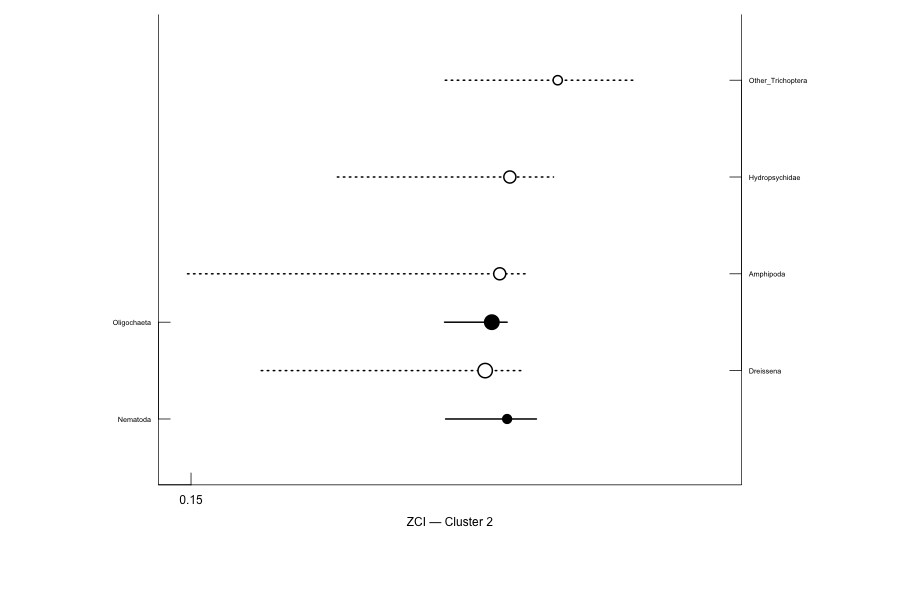

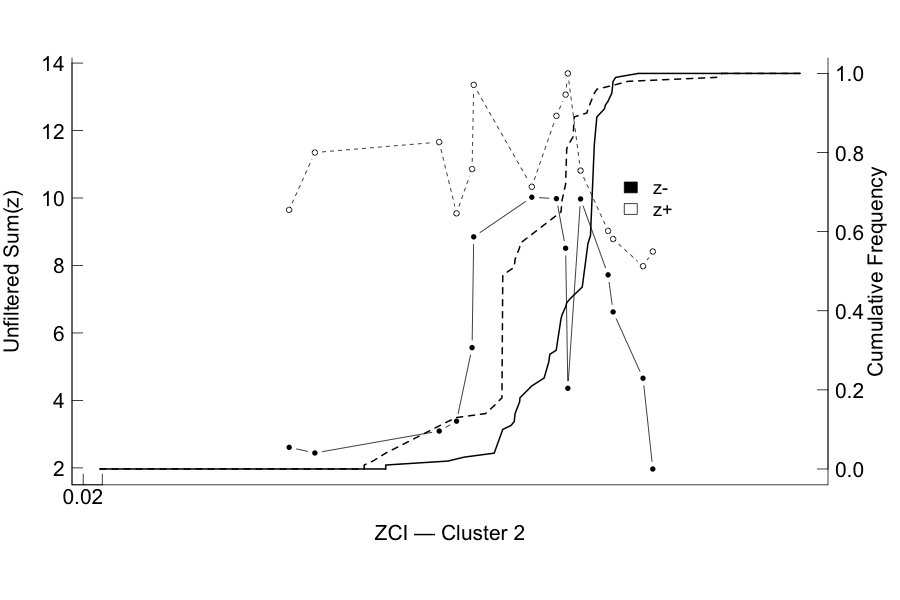

In [43]:
%%R -w 900 -h 600

# ── TITAN diagnostic plots: ZCI gradient ─────────────────────────────
clusters_done_zci <- names(titan_zci_objects)

for (cl in clusters_done_zci) {
    res <- titan_zci_objects[[cl]]

    tryCatch({
        cat("\n━━━ Cluster", cl, "— Taxa Change Points (ZCI) ━━━\n")
        plot_taxa(res, xlabel = paste("ZCI — Cluster", cl))
    }, error = function(e) {
        cat("  ⚠ plot_taxa skipped:", conditionMessage(e), "\n")
    })

    tryCatch({
        cat("\n━━━ Cluster", cl, "— Community Sum(z) (ZCI) ━━━\n")
        plot_sumz(res, xlabel = paste("ZCI — Cluster", cl))
    }, error = function(e) {
        cat("  ⚠ plot_sumz skipped:", conditionMessage(e), "\n")
    })
}

### 2.3  Combined View: Detected Thresholds on ZCI vs Pollution Score Scatter

Below we overlay the TITAN-detected thresholds on the ZCI × Pollution Score scatter plot for each cluster:

- **Vertical lines** (red / blue): Pollution Score community thresholds (z⁻ and z⁺) from §2.1.
- **Horizontal lines** (orange / green): ZCI community thresholds (z⁻ and z⁺) from §2.2.
- **Shaded bands**: 90 % bootstrap confidence intervals for each threshold.

The intersection of the vertical and horizontal threshold bands defines the **critical transition region** in the (Pollution, ZCI) space.

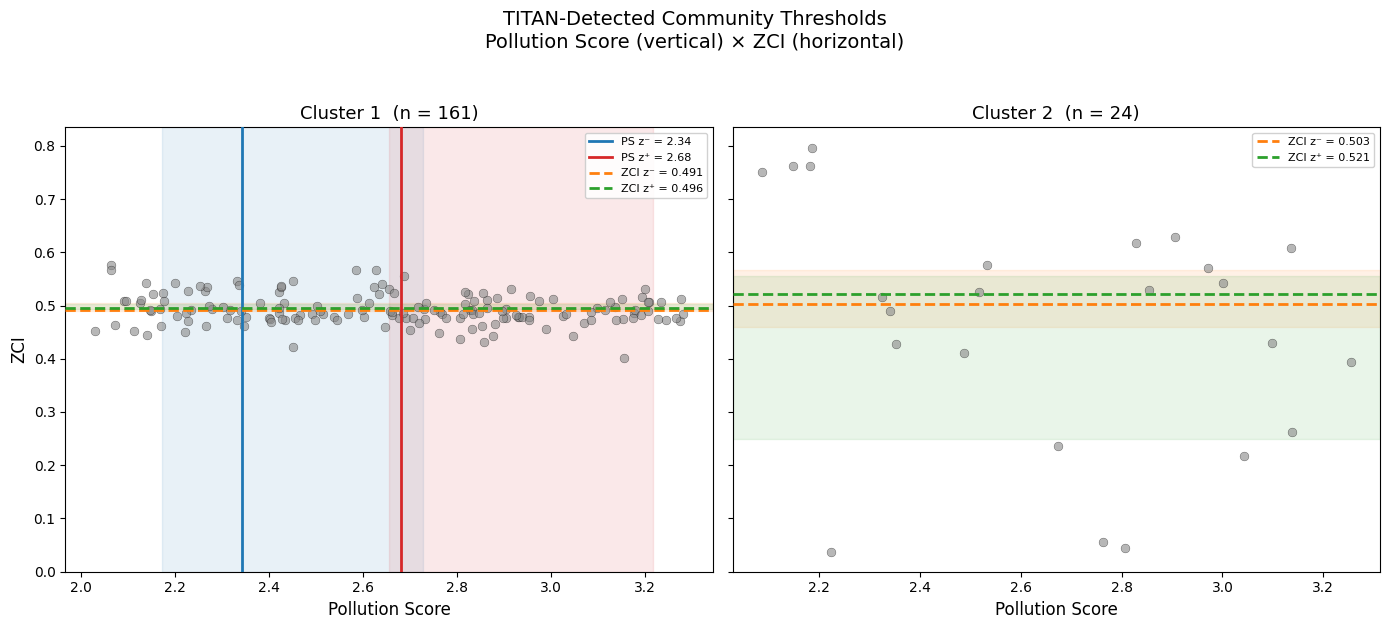

In [44]:
# ── Combined scatter + thresholds ─────────────────────────────────────
import warnings, numpy as _np

n_cl = len(viable_clusters)
fig, axes = plt.subplots(1, n_cl, figsize=(7 * n_cl, 6), squeeze=False, sharey=True)

for i, cl in enumerate(viable_clusters):
    ax  = axes[0, i]
    sub = titan_input[titan_input['Cluster'] == cl]

    # scatter
    ax.scatter(sub['Pollution_Score'], sub['ZCI'],
               c='#888888', edgecolor='k', linewidth=0.3, s=40, alpha=0.6, zorder=2)

    # ── Pollution Score thresholds (vertical) ────────────────────────
    ps_row = sumz_ps_df[sumz_ps_df['Cluster'] == cl]
    if len(ps_row):
        ps_row = ps_row.iloc[0]
        if not _np.isnan(ps_row['zminus_cp']):
            ax.axvline(ps_row['zminus_cp'], color='tab:blue', ls='-', lw=2,
                       label=f"PS z⁻ = {ps_row['zminus_cp']:.2f}", zorder=3)
            ax.axvspan(ps_row['zminus_05'], ps_row['zminus_95'],
                       color='tab:blue', alpha=0.10, zorder=1)
        if not _np.isnan(ps_row['zplus_cp']):
            ax.axvline(ps_row['zplus_cp'], color='tab:red', ls='-', lw=2,
                       label=f"PS z⁺ = {ps_row['zplus_cp']:.2f}", zorder=3)
            ax.axvspan(ps_row['zplus_05'], ps_row['zplus_95'],
                       color='tab:red', alpha=0.10, zorder=1)

    # ── ZCI thresholds (horizontal) ──────────────────────────────────
    zci_row = sumz_zci_df[sumz_zci_df['Cluster'] == cl]
    if len(zci_row):
        zci_row = zci_row.iloc[0]
        if not _np.isnan(zci_row['zminus_cp']):
            ax.axhline(zci_row['zminus_cp'], color='tab:orange', ls='--', lw=2,
                       label=f"ZCI z⁻ = {zci_row['zminus_cp']:.3f}", zorder=3)
            ax.axhspan(zci_row['zminus_05'], zci_row['zminus_95'],
                       color='tab:orange', alpha=0.10, zorder=1)
        if not _np.isnan(zci_row['zplus_cp']):
            ax.axhline(zci_row['zplus_cp'], color='tab:green', ls='--', lw=2,
                       label=f"ZCI z⁺ = {zci_row['zplus_cp']:.3f}", zorder=3)
            ax.axhspan(zci_row['zplus_05'], zci_row['zplus_95'],
                       color='tab:green', alpha=0.10, zorder=1)

    ax.set_xlabel('Pollution Score', fontsize=12)
    ax.set_ylabel('ZCI' if i == 0 else '', fontsize=12)
    ax.set_title(f'Cluster {cl}  (n = {len(sub)})', fontsize=13)
    ax.legend(fontsize=8, loc='best', framealpha=0.9)

fig.suptitle('TITAN-Detected Community Thresholds\n'
             'Pollution Score (vertical) × ZCI (horizontal)',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

### 2.4  Summary and Interpretation

**What TITAN reveals:**

1. **Pollution Score thresholds** (§2.1): the pollution levels at which the benthic community restructures. Below the z⁻ threshold, the community is relatively intact; above the z⁺ threshold, tolerant taxa dominate.

2. **ZCI thresholds** (§2.2): the ZCI values at which community composition shifts. This directly answers *"what ZCI score separates ecologically distinct community states?"*

3. **Combined view** (§2.3): the intersection of the Pollution Score and ZCI thresholds defines a **critical transition region** in the two-dimensional space. Sites inside this region are undergoing active community restructuring — pollution is high enough to trigger decline in sensitive taxa, and the ZCI value reflects the shift.

**Caveats:**
- TITAN was designed for taxa × gradient threshold detection, not for single-variable breakpoint analysis. Using ZCI as a gradient is a creative but non-standard application.
- `nBoot = 100` is used for speed; increase to ≥ 500 for publication.
- Results depend on the cluster assignment from Stage 3 (LDA). Different clustering may yield different thresholds.
- The 20–80 % trimming removes extreme sites; thresholds outside this range are not detectable.